# Lab — Binary Classification and Logistic Models

In this first lab, we explore binary. We gradually move from simple Gaussian mixture models to logistic regression, polynomial feature expansion, ROC analysis, and finally a home-made implementation of logistic regression.

**Objectives:**
- Understand the Bayes classifier in the Gaussian mixture model.
- Implement and visualize the Bayes decision boundary.
- Build a Linear Discriminant Analysis (LDA) classifier.
- Compare LDA to logistic regression.
- Enrich logistic regression with polynomial features.
- Evaluate models using ROC curves and AUC.
- Implement logistic regression *from scratch* with gradient descent.


## 1. Gaussian Mixture and Bayes Classifier

We begin with a simple synthetic binary classification problem:
a **mixture of two Gaussians** with equal covariance matrix.  
In this setting, the **Bayes classifier** is known in closed form and is itself a *linear* classifier.

### Task
1. Implement a class that computes the Bayes decision rule.
2. Display the decision boundary, and experiment with several values of `p` and `rho` (correlation).

The function below will perform the plotting for you.


In [148]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

def sigmoid(z): 
    return 1/(1+np.exp(-z))


class BayesClassifier:
    def __init__(self, p, mu0, mu1, rho):
        self.p = float(p)
        self.mu0 = np.asarray(mu0)
        self.mu1 = np.asarray(mu1)
        Sigma = np.array([[1, rho], [rho, 1]])
        S_inv = np.linalg.inv(Sigma)
        
        # direction vector
        self.w = S_inv @ (self.mu1-self.mu0)# Your code here
        
        # bias term
        t1 = self.mu1 @ S_inv @ self.mu1
        t0 = self.mu0 @ S_inv @ self.mu0
        self.b = (1/2)*(t0-t1)+np.log(p/(1-p))# Your code here

    def decision_function(self, X):
        """Return the linear score w^T x + b."""
        # Your code here
        return np.dot(self.w, X.T)+self.b

    def predict_proba(self, X):
        s = self.decision_function(X)
        p1 = sigmoid(s)
        return np.c_[1 - p1, p1]

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)



In [149]:
def plot_mixture_and_bayes(p, mu0, mu1, rho):
    mu0, mu1 = map(np.asarray, (mu0, mu1))
    Sigma = np.array([[1, rho], [rho, 1]])
    clf = BayesClassifier(p, mu0, mu1, rho)

    # Grid (auto-sized if samples provided)
    x_min, x_max, y_min, y_max = -4, 4, -4, 4

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    G = np.c_[xx.ravel(), yy.ravel()]

    # Gaussian mixture
    f0 = multivariate_normal(mu0, Sigma).pdf(G)
    f1 = multivariate_normal(mu1, Sigma).pdf(G)
    Z = ((1-p)*f0 + p*f1).reshape(xx.shape)

    # Bayes boundary
    post = clf.predict_proba(G)[:,1].reshape(xx.shape)

    # Plot
    plt.figure(figsize=(7,6))
    plt.contourf(xx, yy, Z, levels=20, cmap="viridis")
    plt.contour(xx, yy, Z, colors="k", linewidths=0.4)
    plt.contour(xx, yy, post, levels=[0.5], colors=["#ff0000"], linewidths=2.5)
    
    plt.gca().set_aspect("equal")
    plt.title(f"Mixture level sets + Bayes boundary (p={p}, rho={rho})")
    plt.show()


### Example: Visualizing the Bayes classifier

We now visualize two scenarios:
- balanced and uncorrelated mixture,
- unbalanced and correlated mixture.

Observe how the Bayes boundary changes.


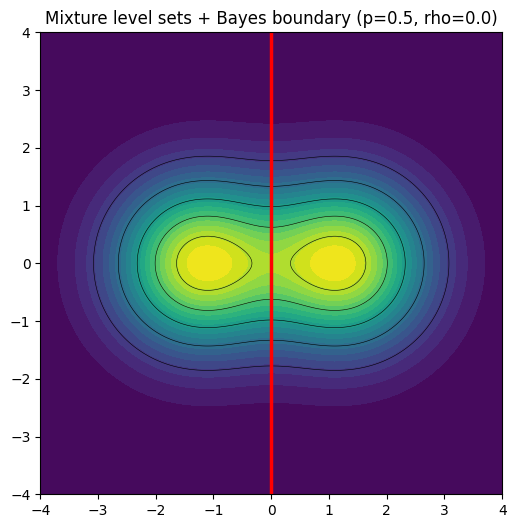

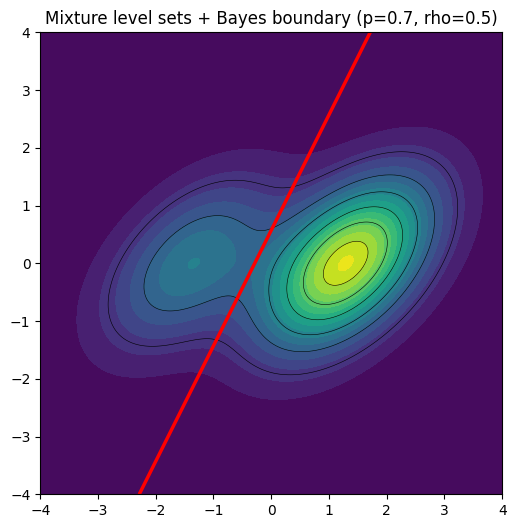

In [150]:
plot_mixture_and_bayes(
    p=0.5, 
    mu0=[-1.25, 0], 
    mu1=[+1.25, 0], 
    rho=0.0
)

# Now your turn, with unbalanced and correlated features

# Your code here
plot_mixture_and_bayes(
    p=0.7, 
    mu0=[-1.4, 0], 
    mu1=[+1.3, 0], 
    rho=0.5
)

## 2. Generating Data From a Gaussian Mixture

We now generate labeled samples from  

$(1-p)\, \mathcal N(\mu_0, \Sigma) \quad \text{and} \quad
p\, \mathcal N(\mu_1, \Sigma),$
and we will train classifiers on this data.

### Task
- Understand the `generate_mixture_samples` function.
- Generate datasets for multiple parameter choices.


In [151]:
def generate_mixture_samples(n, p, mu0, mu1, rho, random_state=None):
    """
    Generate n samples from the 2D Gaussian mixture:
        (1-p) N(mu0, Sigma) + p N(mu1, Sigma)
    with Sigma = [[1, rho], [rho, 1]].
    Returns X (n,2) and y (n,) in {0,1}.
    """
    rng = np.random.default_rng(random_state)
    mu0, mu1 = np.asarray(mu0), np.asarray(mu1)
    Sigma = np.array([[1, rho], [rho, 1]])
    
    # sample class labels
    y = rng.binomial(1, p, size=n)
    
    # sample from multivariate normal according to classes
    X = np.zeros((n, 2))
    idx1 = (y == 1)
    idx0 = ~idx1
    
    if idx0.any():
        X[idx0] = multivariate_normal(mu0, Sigma).rvs(size=idx0.sum(), random_state=rng)
    if idx1.any():
        X[idx1] = multivariate_normal(mu1, Sigma).rvs(size=idx1.sum(), random_state=rng)
    
    return X, y


### Visualizing the sampled dataset

We now generate 500 samples and visualize the resulting clusters.
This will serve as our training data for LDA and logistic regression later on.


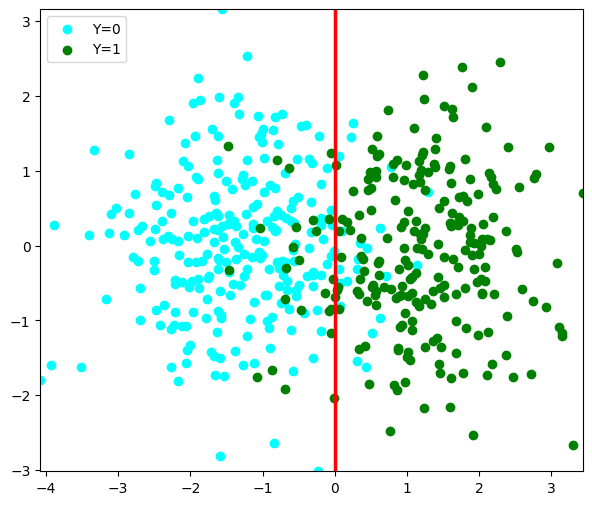

In [152]:
p   = 0.5
mu0 = [-1.25, 0]
mu1 = [ 1.25, 0]
rho = 0.0

# Your code here
X,y= generate_mixture_samples(500, p, mu0, mu1, rho)

Bay = BayesClassifier(p, mu0, mu1, rho)
def plot(X,y):
    x_min = np.min(X[:, 0]); x_max = np.max(X[:,0])
    y_min = np.min(X[:, 1]); y_max = np.max(X[:,1])

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    G = np.c_[xx.ravel(), yy.ravel()]
    post = Bay.predict_proba(G)[:,1].reshape(xx.shape)
    plt.figure(figsize=(7,6))
    plt.scatter(X[y==0, 0], X[y==0, 1], color='cyan', label='Y=0')
    plt.scatter(X[y==1, 0], X[y==1, 1], color='green', label='Y=1')
    plt.contour(xx, yy, post, levels=[0.5], colors=["#ff0000"], linewidths=2.5)
    plt.legend()

plot(X,y)

## 3. Linear Discriminant Analysis (LDA)

LDA is a **generative binary classifier** based on the assumption:

- both classes are Gaussian,
- with the **same covariance matrix** but different means.

Under these assumptions, the Bayes classifier is linear and can be estimated from data.

### Task
- Complete the LDA classifier below.
- Understand how `mu0`, `mu1`, and the shared covariance are estimated.


In [153]:
class LDAClassifier:
    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, int)
        
        X0, X1 = X[y == 0], X[y == 1]
        n0, n1 = len(X0), len(X1)
        self.p_ = n1 / (n0 + n1)
        
        # means
        sum1 = np.sum([X[i]* (1-y[i]) for i in range(n0+n1)], axis=0)
        sum2 = np.sum([X[i]* y[i] for i in range(n0+n1)],axis=0)
        self.mu0_, self.mu1_ = sum1/np.sum(1-y), sum2/np.sum(y)# Your code here
        
        # pooled covariance
        # S = np.zeros((len(self.mu0_), len(self.mu0_)))# Your code here
        # for i in range(len(X)):
        #     if y[i]==0:
        #         term0 = (X[i]-self.mu0_)
        #         S+= 1/(n0+n1)*term0 @ term0.T
        #     else:
        #         term1 = (X[i]-self.mu1_)
        #         S += 1/(n0+n1)* term1 @ term1.T
        term0 = X0-self.mu0_
        term1 = X1-self.mu1_
        S = (term0.T @ term0 + term1.T @ term1)/(n0+n1)
        S_inv = np.linalg.inv(S)
        
        # linear discriminant parameters
        self.w_ = S_inv @ (self.mu1_ - self.mu0_)# Your code here
        t1 = self.mu1_ @ S_inv @ self.mu1_
        t0 = self.mu0_ @ S_inv @ self.mu0_
        self.b_ = (1/2)*(t0-t1) + np.log(p/(1-p))# Your code here

        return self

    def decision_function(self, X):
        """Return the linear score w^T x + b."""
        # Your code here
        return np.dot(self.w_, X.T)+self.b_

    def predict_proba(self, X):
        # Your code here
        s = self.decision_function(X)
        p1 = sigmoid(s)
        return np.c_[1 - p1, p1]

    def predict(self, X):
        # Your code here
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)



### Training and Evaluating LDA

We split the dataset into **training** and **test** sets.

### Task
- Train LDA using the training set.
- Evaluate prediction accuracy on the test set. 
- Print predicted probabilities for a few examples.
- Understand the structure of the predicted probabilities


In [154]:
# --- generate data from mixture ---
p   = 0.5
mu0 = [-1.25, 0]
mu1 = [ 1.25, 0]
rho = 0.3

X, y = generate_mixture_samples(500, p, mu0, mu1, rho, random_state=0)

# --- train/test split ---
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# --- fit LDA ---
lda = LDAClassifier()# Your code here
lda=lda.fit(X_train, y_train)

# --- predict on first 5 test points ---
print("Test points:\n", X_test[:5])
print("True labels :", y_test[:5])
print("Predicted   :", lda.predict(X_test[:5]))
print("Predict proba:\n", lda.predict_proba(X_test[:5]))


Test points:
 [[ 1.14043505 -0.47432458]
 [-2.17615179  0.05386393]
 [-0.58474358  2.10801622]
 [ 1.58569423  0.68637463]
 [-1.88289474 -0.63697667]]
True labels : [1 0 0 1 0]
Predicted   : [1 0 0 1 0]
Predict proba:
 [[0.02597302 0.97402698]
 [0.99828602 0.00171398]
 [0.94775658 0.05224342]
 [0.01394687 0.98605313]
 [0.99402286 0.00597714]]


### Comparing LDA and Bayes Boundaries

Here we compare the decision boundaries:
- **LDA** (estimated from finite data)
- **Bayes** (the true optimal classifier)

### Question
- When do you expect LDA to match the Bayes classifier?
- What happens when the sample size is small?


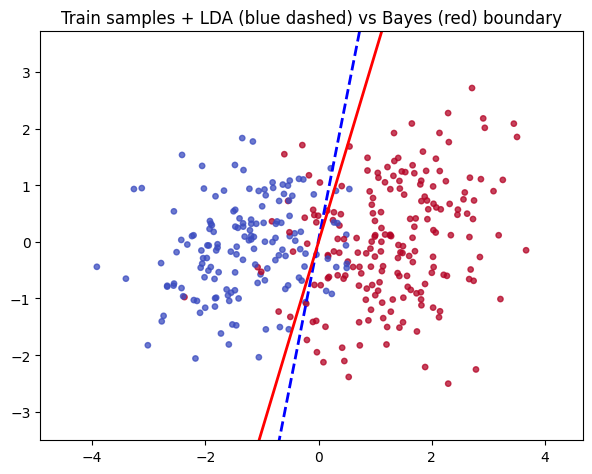

In [155]:
bayes = BayesClassifier(p, mu0, mu1, rho)

# --- grid (based on train set) ---
x_min, x_max = X_train[:,0].min()-1, X_train[:,0].max()+1
y_min, y_max = X_train[:,1].min()-1, X_train[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
G = np.c_[xx.ravel(), yy.ravel()]

post_lda   = lda.predict_proba(G)[:,1].reshape(xx.shape)
post_bayes = bayes.predict_proba(G)[:,1].reshape(xx.shape)

# --- plot ---
plt.figure(figsize=(7,6))
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap="coolwarm",s=15, alpha=0.75)

# LDA boundary (blue)
plt.contour(xx, yy, post_lda, levels=[0.5], colors=["#0000ff"], linewidths=2, linestyles="--")
# Bayes boundary (bright red)
plt.contour(xx, yy, post_bayes, levels=[0.5], colors=["#ff0000"], linewidths=2)

plt.gca().set_aspect("equal")
plt.title("Train samples + LDA (blue dashed) vs Bayes (red) boundary")
plt.show()


Evaluate the accuracy of the LDA classifier on the test set

In [156]:
# LDA accuracy on test set
# Your code here
y_pred = lda.predict(X_test)
acc = np.sum(y_test == y_pred)/len(X_test)
print(f"Accuracy : {acc}")

Accuracy : 0.9066666666666666


### Double moons

We now use the double moons dataset, whose classes are clearly non-Gaussian.
Although LDA’s assumptions do not hold here, we can still train it and observe the resulting decision boundary and compare it with logistic regression.


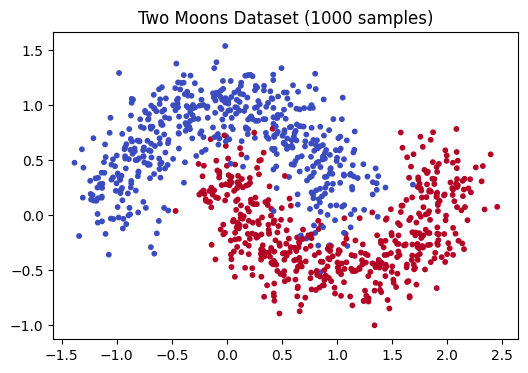

In [157]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# generate data
X, y = make_moons(n_samples=1000, noise=0.2, random_state=0)

# scatter plot
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", s=10)
plt.gca().set_aspect("equal")
plt.title("Two Moons Dataset (1000 samples)")
plt.show()


In [158]:
from sklearn.model_selection import train_test_split

# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)# Your code here

# fit LDA
# Your code here
lda = LDAClassifier()
lda.fit(X_train, y_train)

# accuracy on test set
# Your code here
y_pred_lda = lda.predict(X_test)
acc = np.sum(y_test == y_pred_lda)/len(X_test)
print(f"Accuracy : {acc}")

Accuracy : 0.8333333333333334


Now let us visualize the decision boundary

In [159]:
def plot_points_and_boundary(clf, X, y, title="Decision boundary"):
    X, y = np.asarray(X), np.asarray(y)

    # grid around data
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    G = np.c_[xx.ravel(), yy.ravel()]

    # posterior for class 1 (assuming sklearn-style predict_proba)
    post = clf.predict_proba(G)[:,1].reshape(xx.shape)

    # plot
    plt.figure(figsize=(6,5))
    plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm",
                s=12, alpha=0.7)
    plt.contour(xx, yy, post, levels=[0.5], colors=["#0000ff"], linewidths=2)

    plt.gca().set_aspect("equal")
    plt.title(title)
    plt.show()


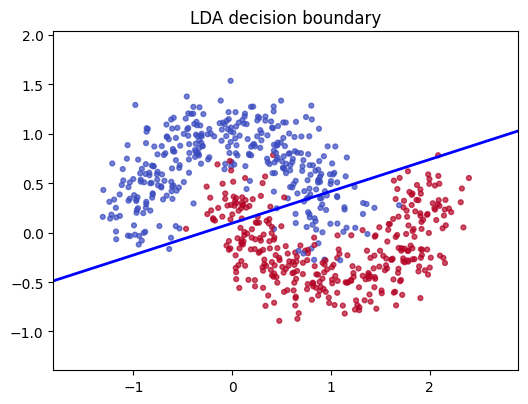

In [160]:
plot_points_and_boundary(lda, X_train, y_train, title="LDA decision boundary")


## 4. Logistic Regression

We now switch to a **discriminative** model: logistic regression.

### Objectives
- Fit a logistic classifier to the mixture data.
- Compare its decision boundary with LDA and Bayes.
- Explore improvements using **polynomial feature expansion**.


Accuracy : 0.8366666666666667


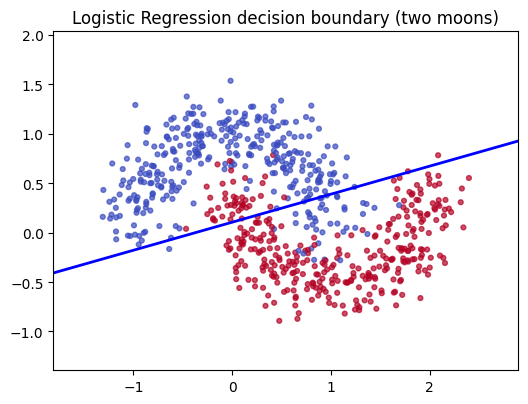

In [161]:
from sklearn.linear_model import LogisticRegression

# --- fit Logistic Regression ---
lr = LogisticRegression()# Your code here

# --- accuracy ---
# Your code here
lr.fit(X_train, y_train)
y_pred_lr=lr.predict(X_test)
acc = np.sum(y_test == y_pred_lr)/len(X_test)
print(f"Accuracy : {acc}")
# --- display decision boundary ---
plot_points_and_boundary(lr, X_train, y_train,
                         title="Logistic Regression decision boundary (two moons)")


Accuracy : 0.95


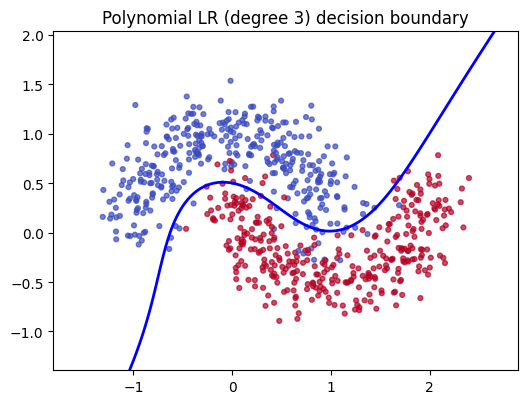

In [162]:
from sklearn.preprocessing import PolynomialFeatures

k = 3  # polynomial degree

# --- polynomial transform ---
poly = PolynomialFeatures(k, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

# --- fit LR on polynomial features ---
lr_poly = lr.fit(X_train_poly, y_train)# Your code here

# --- accuracy ---
# Your code here
y_pred_poly=lr.predict(X_test_poly)
acc = np.sum(y_test == y_pred_poly)/len(X_test)
print(f"Accuracy : {acc}")
# --- decision boundary plot (on original X grid) ---
# we wrap clf so plot_points_and_boundary can call predict_proba on raw X

class PolyWrapper:
    def __init__(self, poly, clf):
        self.poly = poly
        self.clf = clf
    def predict_proba(self, X):
        return self.clf.predict_proba(self.poly.transform(X))

plot_points_and_boundary(
    PolyWrapper(poly, lr_poly),
    X_train,
    y_train,
    title=f"Polynomial LR (degree {k}) decision boundary"
)


### Task: Increase the polynomial degree

Increase the value of \(k\) in the polynomial features and observe how the decision boundary evolves.  
To clearly see the effect **without regularization**, do **not** use the default scikit-learn setting.  
Instead, set: C = 1e9, so that regularization is essentially removed.  
Discuss what happens as \(k\) becomes large.

Accuracy : 0.9733333333333334


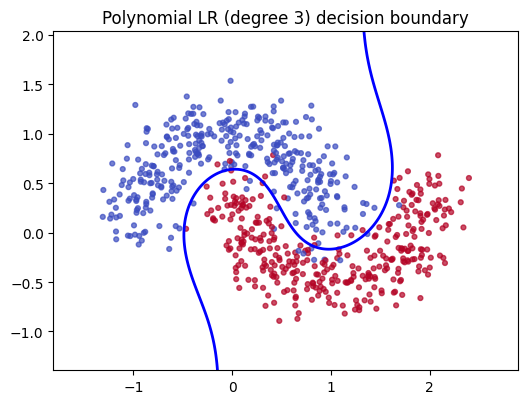

Accuracy : 0.9666666666666667


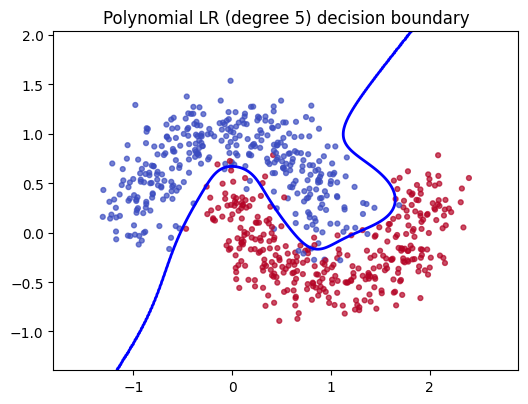

Accuracy : 0.9633333333333334


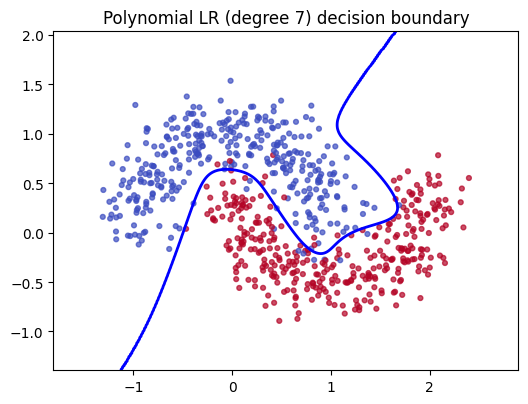

Accuracy : 0.96


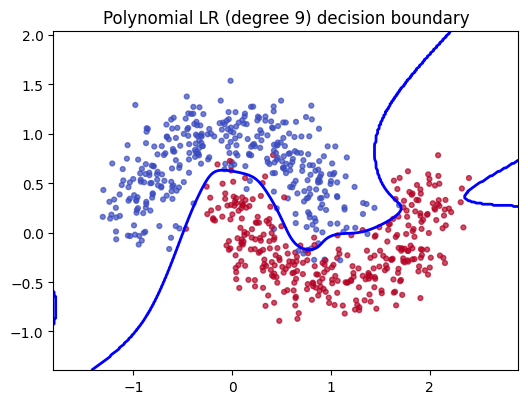

Accuracy : 0.96


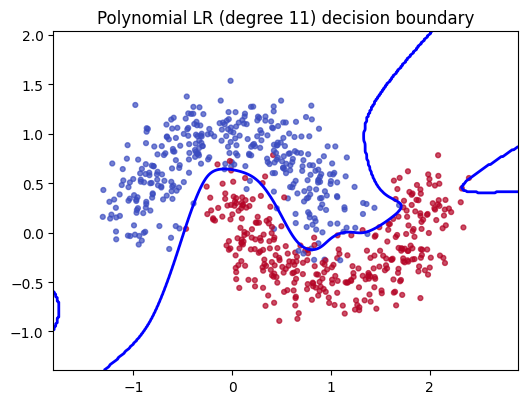

C:\Users\moham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 8639 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy : 0.9633333333333334


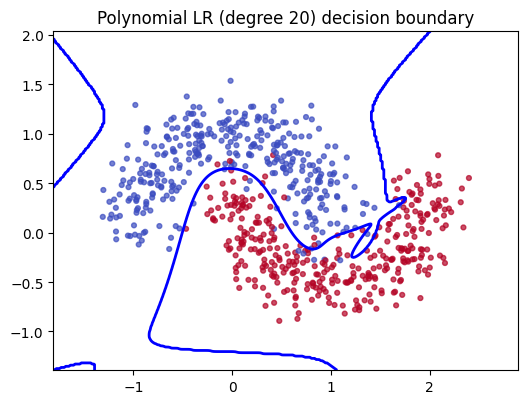

In [163]:
# Your code here
from sklearn.preprocessing import PolynomialFeatures

ks = [3, 5, 7, 9, 11, 20]  # polynomial degree

# --- polynomial transform ---
for k in ks:
    lr = LogisticRegression(C=1e9, max_iter=100000)
    poly = PolynomialFeatures(k, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly  = poly.transform(X_test)

    # --- fit LR on polynomial features ---
    lr_poly = lr.fit(X_train_poly, y_train)

    # --- accuracy ---
    y_pred=lr.predict(X_test_poly)
    acc = np.sum(y_test == y_pred)/len(X_test)
    print(f"Accuracy : {acc}")
    # --- decision boundary plot (on original X grid) ---
    # we wrap clf so plot_points_and_boundary can call predict_proba on raw X

    plot_points_and_boundary(
        PolyWrapper(poly, lr_poly),
        X_train,
        y_train,
        title=f"Polynomial LR (degree {k}) decision boundary"
    )


We see here that the result is getting less accurate when we increase k. Which means that for this situation, the best degree is ``k=3``.

## 5. ROC Curves and AUC

Accuracy alone is often insufficient.  
We now compare models using **ROC curves** and the **Area Under the Curve (AUC)**.

### Models compared:
- LDA
- Logistic regression
- Logistic regression with polynomial features (degree 3)

### Task
- Generate ROC curves for the three models.
- Compare their AUCs.
- Comment on which model is best and why.


In [167]:
from sklearn.metrics import roc_curve, roc_auc_score

# Your code here

curve_lda=roc_curve(y_test, y_pred_lda)
auc_lda = roc_auc_score(y_test, y_pred_lda)

curve_lr=roc_curve(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_pred_lr)

curve_poly=roc_curve(y_test, y_pred_poly)
auc_poly = roc_auc_score(y_test, y_pred_poly)

print(f"For LDA : Roc curve :\n {curve_lda}, Roc Auc Score : {auc_lda} \n")
print(f"For LR : Roc curve :\n {curve_lr}, Roc Auc Score : {auc_lr} \n")
print(f"For LR with polynomial features :\n Roc curve : {curve_poly}, Roc Auc Score : {auc_poly} \n")

For LDA : Roc curve :
 (array([0.        , 0.17931034, 1.        ]), array([0.        , 0.84516129, 1.        ]), array([inf,  1.,  0.])), Roc Auc Score : 0.8329254727474973 

For LR : Roc curve :
 (array([0.        , 0.16551724, 1.        ]), array([0.        , 0.83870968, 1.        ]), array([inf,  1.,  0.])), Roc Auc Score : 0.8365962180200224 

For LR with polynomial features :
 Roc curve : (array([0.        , 0.05517241, 1.        ]), array([0.        , 0.95483871, 1.        ]), array([inf,  1.,  0.])), Roc Auc Score : 0.9498331479421579 



## 6. Implementing Logistic Regression From Scratch

To deepen your understanding, you will build your own logistic regression class.

### Task
- Implement the gradient descent.


In [189]:
import numpy as np

class myLogisticRegression:
    def __init__(self, lr=0.1, max_iter=1000):
        self.lr = lr
        self.max_iter = max_iter
        self.loss_history = []       # <--- NEW

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        n, d = X.shape

        # add intercept
        Xb = np.c_[np.ones(n), X]
        self.w = np.zeros(d + 1)

        for _ in range(self.max_iter):
            scores = Xb @ self.w# Your code here
            p1 = self.sigmoid(scores)

            # Binary cross-entropy loss
            loss = loss = - np.mean(y*np.log(p1) + (1-y)*np.log(1-p1))# Your code here
            self.loss_history.append(loss)

            # Gradient descent
            grad = (1/n)* (Xb.T @ (p1-y))# Your code here
            self.w -= self.lr * grad

        return self
    
    def predict_proba(self, X):
        Xb = np.c_[np.ones(len(X)), X]
        p1 = self.sigmoid(Xb @ self.w)
        return np.c_[1 - p1, p1]
    
    def predict(self, X):
        return (self.predict_proba(X)[:,1] >= 0.5).astype(int)


### Training Loss Curve

We now train our custom logistic model and visualize the **training loss**.

### Question
- Is the loss decreasing monotonically?
- What happens if you use a learning rate that’s too large? too small?


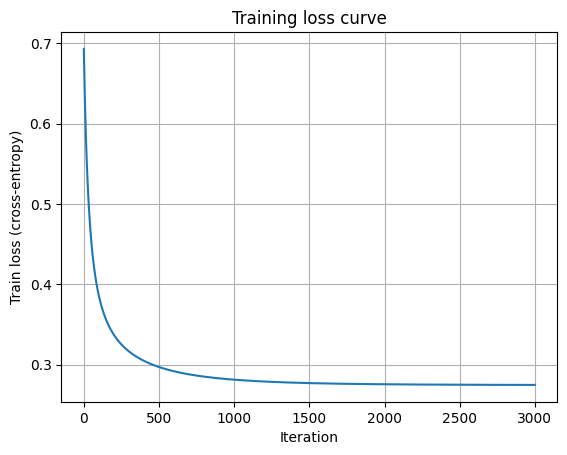

In [190]:
clf = myLogisticRegression(lr=0.1, max_iter=3000)
clf.fit(X_train, y_train)

import matplotlib.pyplot as plt
plt.plot(clf.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Train loss (cross-entropy)")
plt.title("Training loss curve")
plt.grid(True)
plt.show()


Evaluate the accuracy

In [191]:
# Your code here
mylr = myLogisticRegression()
mylr=mylr.fit(X_train, y_train)
y_pred_mylr=mylr.predict(X_test)



In [192]:
acc = np.mean(y_pred_mylr==y_test)
print(f"Accuracy : {acc}")

curve_mylr=roc_curve(y_test, y_pred_mylr)
auc_mylr = roc_auc_score(y_test, y_pred_mylr)

print(f"For myLogisticRegression : Roc curve :\n {curve_mylr}, Roc Auc Score : {auc_mylr} \n")

Accuracy : 0.8366666666666667
For myLogisticRegression : Roc curve :
 (array([0.        , 0.17241379, 1.        ]), array([0.        , 0.84516129, 1.        ]), array([inf,  1.,  0.])), Roc Auc Score : 0.8363737486095663 

